**Assingment Lecture 5**
Submit the following exercises:

Submit 4.16 for logistic regression only

Submit 6.11.a for LASSO and ridge only

Q16 : Using the Boston data set, ft classifcation models in order to predict
whether a given suburb has a crime rate above or below the median.
Explore logistic regression, LDA, naive Bayes, and KNN models using
various subsets of the predictors. Describe your fndings.

## **Ques 16 Ans :**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Load Boston dataset from the CSV file
file_path = '/content/drive/MyDrive/DATA602/Boston.csv'
data = pd.read_csv(file_path)
feature_names = data.columns  # Get the column names from the CSV

# Create a DataFrame with the same feature names (already done via read_csv)
data = pd.DataFrame(data=data.values, columns=feature_names)

# Check the shape of the dataset (rows, columns)
print(data.shape)

# Display the first few rows of the dataset
data.head()
# Create a new column 'CRIM01' where values are set to 1 if 'CRIM' is above the median, otherwise 0
median_crim = data['crim'].median()
data['CRIM01'] = (data['crim'] > median_crim).astype(int)

# Display the distribution of the new 'CRIM01' variable as proportions of the total dataset
print(data['CRIM01'].value_counts(normalize=True))

# Remove the original 'CRIM' column from the dataset
data = data.drop(columns=['crim'])
# Calculate the correlation matrix for all features
correlation_matrix = data.corr()
# Extract and sort correlations with respect to 'CRIM01', excluding 'CRIM01' itself
sorted_corr = correlation_matrix['CRIM01'].drop('CRIM01').sort_values(ascending=False)
# Display sorted correlations
print("Sorted correlations with 'CRIM01' (from highest to lowest):\n")
print(sorted_corr)


(506, 14)
CRIM01
0    0.5
1    0.5
Name: proportion, dtype: float64
Sorted correlations with 'CRIM01' (from highest to lowest):

nox           0.723235
rad           0.619786
age           0.613940
tax           0.608741
indus         0.603260
lstat         0.453263
Unnamed: 0    0.369430
ptratio       0.253568
chas          0.070097
rm           -0.156372
medv         -0.263017
zn           -0.436151
dis          -0.616342
Name: CRIM01, dtype: float64


In [ ]:
# Define all features
all_features = [col for col in data.columns if col != 'CRIM01']
print('Total features are', len(all_features))

# Explicitly define the selected features
selected_features = ['nox', 'rad', 'age', 'tax', 'indus', 'dis']
print('Selected features are', len(selected_features))
target_variable = data['CRIM01']
# Create a new DataFrame without the target variable
data_without_target = data.drop(columns=['CRIM01'])
# Create a DataFrame that excludes the selected features
data_selected = data.drop(columns=selected_features)
data_selected = data_selected.drop(columns=['CRIM01'], errors='ignore')
data_selected.head()
# Split the dataset into training and testing sets for original and selected features
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(data_without_target, target_variable, test_size=0.2, random_state=0)
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(data_selected, target_variable, test_size=0.2, random_state=0)

# Function to analyze the confusion matrix and accuracy
def evaluate_confusion_matrix_and_accuracy(actual, predicted):
    confusion_mat = confusion_matrix(actual, predicted)
    conf_matrix_df = pd.DataFrame(confusion_mat, index=['0', '1'], columns=['0', '1'])
    print(conf_matrix_df)
    print('')
    print('Total actual 0 values:', conf_matrix_df.iloc[0, :].sum())
    print('Total actual 1 values:', conf_matrix_df.iloc[1, :].sum())
    print('Total predicted 0 values:', conf_matrix_df.iloc[:, 0].sum())
    print('Total predicted 1 values:', conf_matrix_df.iloc[:, 1].sum())
    print('')
    print('% of 1 values in dataset:', conf_matrix_df.iloc[1, :].sum() / (conf_matrix_df.iloc[0, :].sum() + conf_matrix_df.iloc[1, :].sum()))
    print('% of 1 values in predictions:', conf_matrix_df.iloc[:, 1].sum() / (conf_matrix_df.iloc[:, 1].sum() + conf_matrix_df.iloc[:, 0].sum()))
    print()
    print('Accuracy:', accuracy_score(actual, predicted))

# Logistic Regression on selected features
print("Training Logistic Regression model on selected features...")
logistic_regression_selected = LogisticRegression()
logistic_regression_selected.fit(X_train_selected, y_train_selected)

print("Making predictions on the test set for selected features...")
predictions_selected = logistic_regression_selected.predict(X_test_selected)

print("Evaluating performance on selected features...")
evaluate_confusion_matrix_and_accuracy(y_test_selected, predictions_selected)

# Logistic Regression on original features
print("\nTraining Logistic Regression model on original features...")
logistic_regression_full = LogisticRegression()
logistic_regression_full.fit(X_train_full, y_train_full)

print("Making predictions on the test set for original features...")
predictions_full = logistic_regression_full.predict(X_test_full)

print("Evaluating performance on original features...")
evaluate_confusion_matrix_and_accuracy(y_test_full, predictions_full)


Total features are 13
Selected features are 6
Training Logistic Regression model on selected features...
Making predictions on the test set for selected features...
Evaluating performance on selected features...
    0   1
0  35  16
1   9  42

Total actual 0 values: 51
Total actual 1 values: 51
Total predicted 0 values: 44
Total predicted 1 values: 58

% of 1 values in dataset: 0.5
% of 1 values in predictions: 0.5686274509803921

Accuracy: 0.7549019607843137

Training Logistic Regression model on original features...
Making predictions on the test set for original features...
Evaluating performance on original features...
    0   1
0  44   7
1   8  43

Total actual 0 values: 51
Total actual 1 values: 51
Total predicted 0 values: 52
Total predicted 1 values: 50

% of 1 values in dataset: 0.5
% of 1 values in predictions: 0.49019607843137253

Accuracy: 0.8529411764705882


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

## **Ques 6.11A - Lasso and Ridge Ans :**

Shape of the dataset: (506, 14)


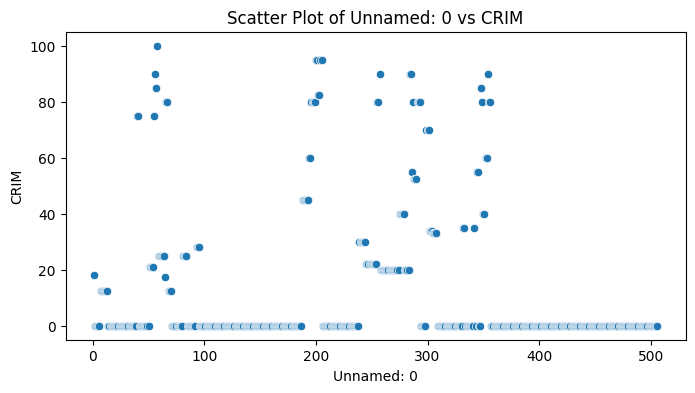

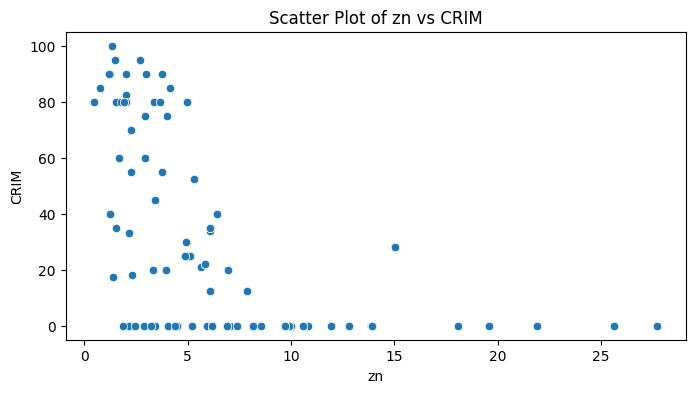

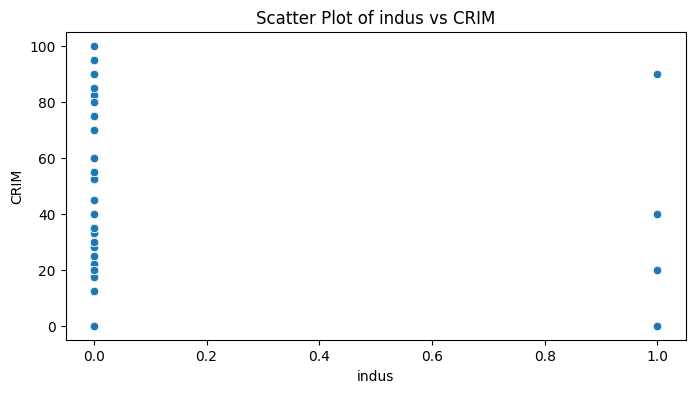

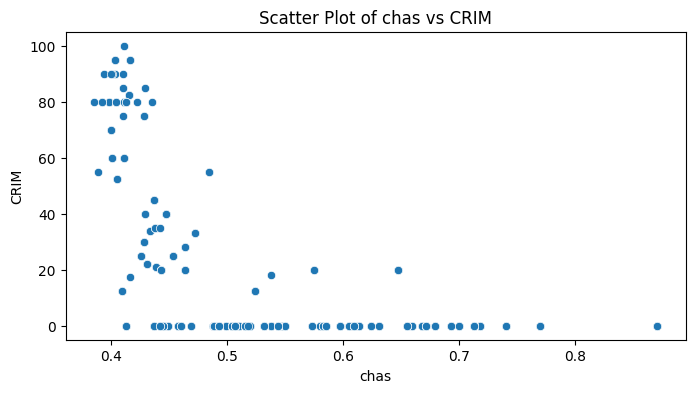

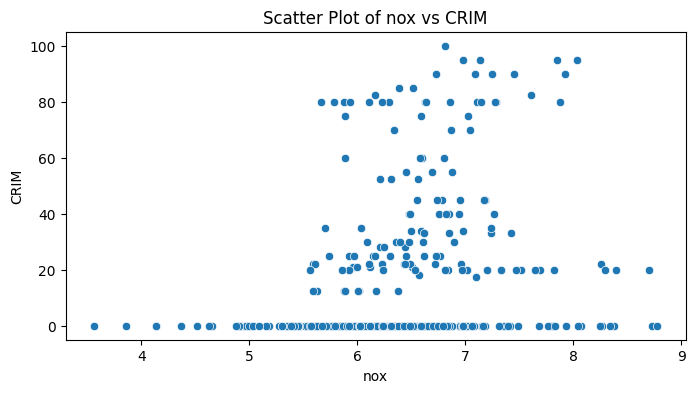

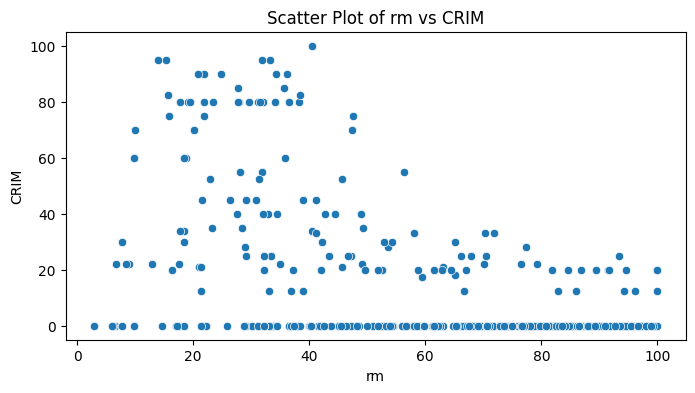

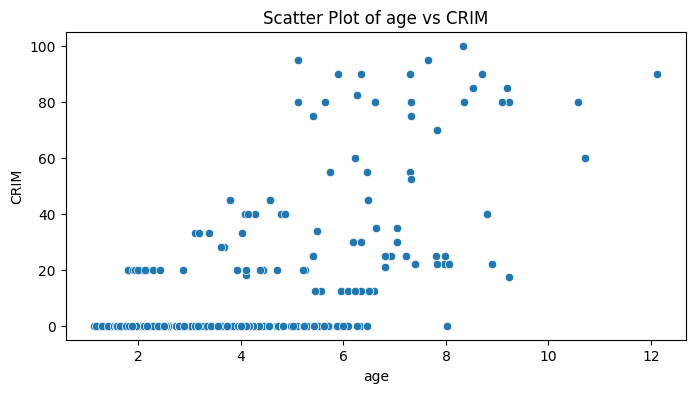

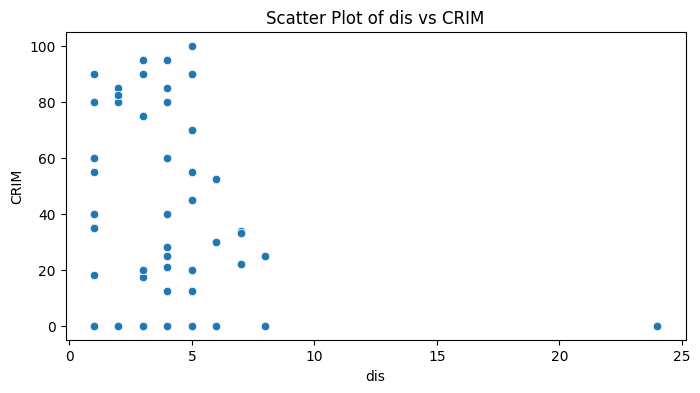

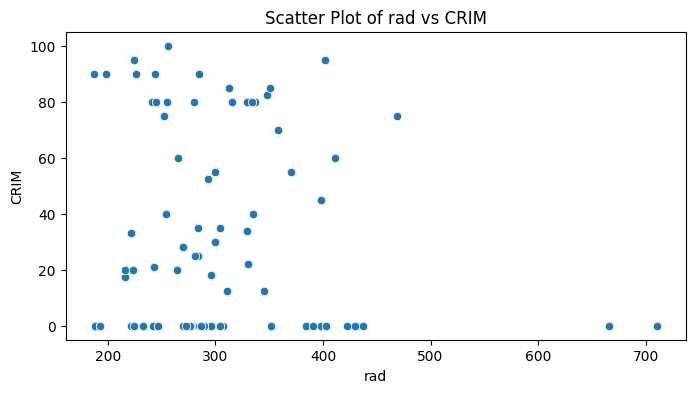

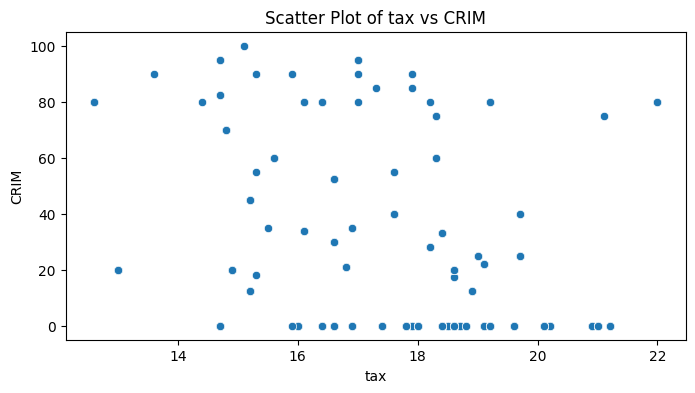

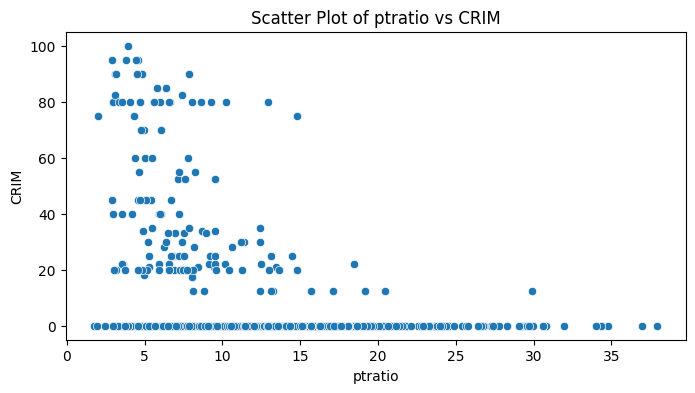

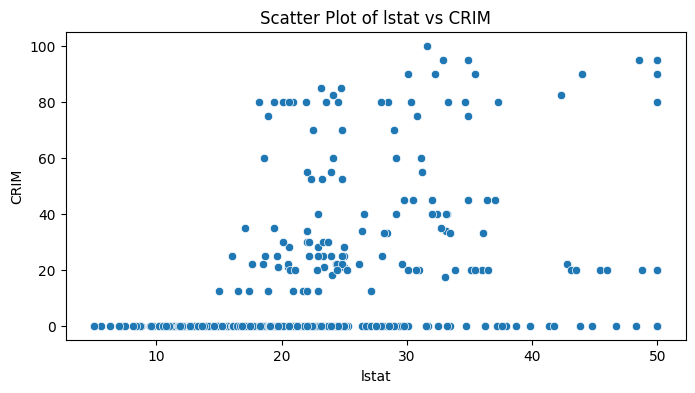

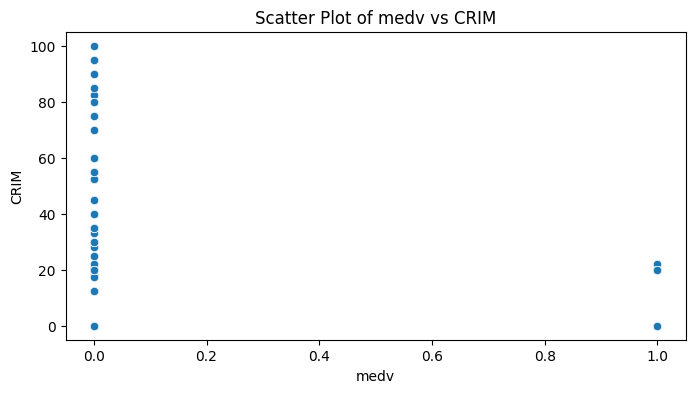


Best score for Ridge Regression:
 0.5754425266070595


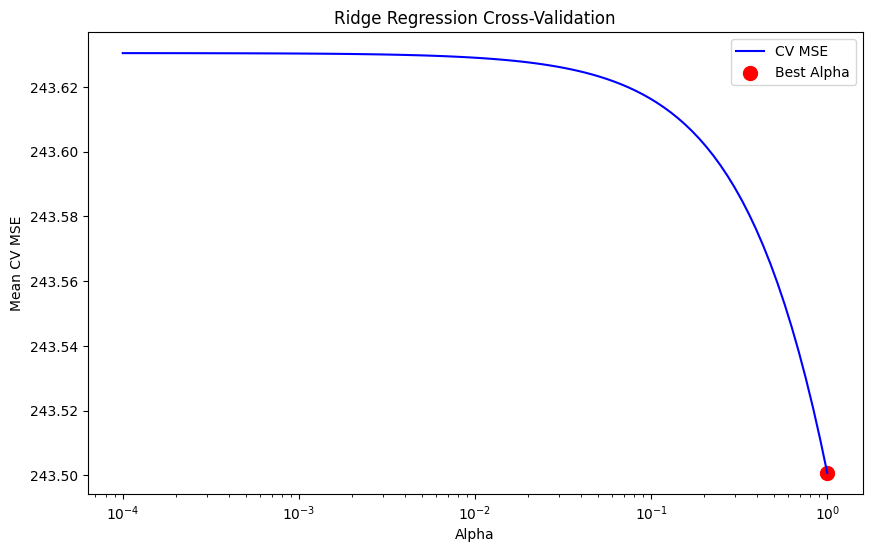


Ridge Regression Coefficients:
 Intercept     11.363636
Unnamed: 0     2.126789
zn            -3.205929
indus         -0.221920
chas           0.076840
nox            1.996862
rm            -2.595734
age           13.196952
dis           -4.510054
rad            9.880488
tax           -5.422243
ptratio        3.631322
lstat          4.193073
medv          -1.398868
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
# Create a DataFrame with the same feature names
data = pd.DataFrame(data=data.values, columns=feature_names)

# Display the shape of the dataset
print("Shape of the dataset:", data.shape)

# Define predictors and target variable
X = data.drop('crim', axis=1)
y = data['crim']

# Scale the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize relationships between predictors and the target variable
for feature in X.columns:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=X[feature], y=y)
    plt.title(f'Scatter Plot of {feature} vs CRIM')
    plt.xlabel(feature)
    plt.ylabel('CRIM')
    plt.show()

# Initialize results storage
results = {}

# Ridge Regression with Cross-Validation
ridge_model = RidgeCV(alphas=10**np.linspace(-4, 0, 100), store_cv_results=True)
ridge_model.fit(X_scaled, y)

# Evaluate Ridge Regression
ridge_score = ridge_model.score(X_scaled, y)
results['Ridge'] = ridge_score
print("\nBest score for Ridge Regression:\n", ridge_score)

# Cross-validation values and plotting
mse_cv_ridge = np.mean(ridge_model.cv_results_, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(ridge_model.alphas, mse_cv_ridge, label='CV MSE', color='blue')
plt.scatter(ridge_model.alpha_, np.min(mse_cv_ridge), marker='o', color='red', s=100, label='Best Alpha')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean CV MSE')
plt.title('Ridge Regression Cross-Validation')
plt.legend()
plt.show()

# Display coefficients from Ridge Regression
ridge_coefficients = pd.Series(np.hstack([ridge_model.intercept_, ridge_model.coef_]), index=['Intercept'] + list(X.columns))
print("\nRidge Regression Coefficients:\n", ridge_coefficients)

Best score for Lasso Regression: 0.5490172177932713


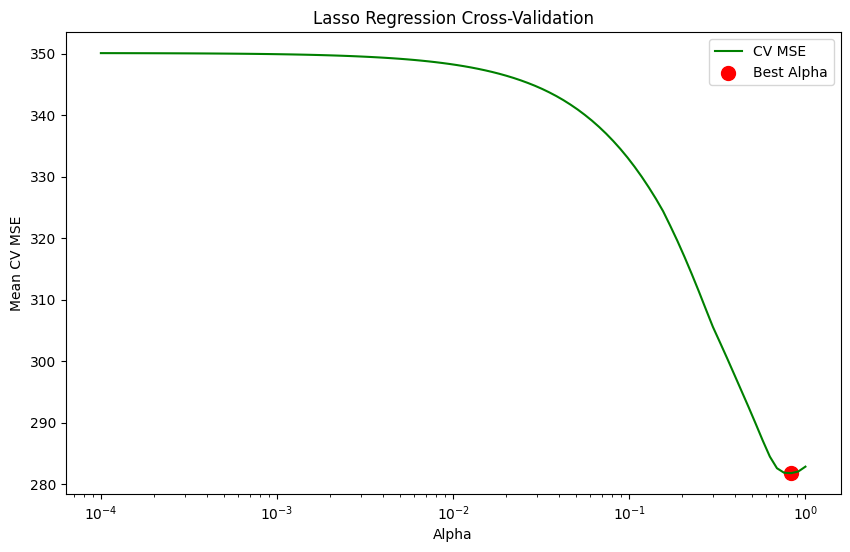

Lasso Regression Coefficients:
 Intercept     11.363636
Unnamed: 0     1.581188
zn            -0.525550
indus         -0.000000
chas          -0.000000
nox            1.113384
rm            -1.759524
age           12.793080
dis            0.000000
rad            2.392199
tax           -4.967207
ptratio        0.000000
lstat          1.571810
medv          -0.242973
dtype: float64


In [ ]:
# Lasso Regression with Cross-Validation
lasso_model = LassoCV(alphas=10**np.linspace(-4, 0, 100), cv=5)
lasso_model.fit(X_scaled, y)

# Evaluate Lasso Regression
lasso_score = lasso_model.score(X_scaled, y)
results['Lasso'] = lasso_score
print("Best score for Lasso Regression:", lasso_score)

# Mean squared error for Lasso and plotting
mse_cv_lasso = np.mean(lasso_model.mse_path_, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(lasso_model.alphas_, mse_cv_lasso, label='CV MSE', color='green')
plt.scatter(lasso_model.alpha_, np.min(mse_cv_lasso), marker='o', color='red', s=100, label='Best Alpha')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean CV MSE')
plt.title('Lasso Regression Cross-Validation')
plt.legend()
plt.show()

# Display coefficients from Lasso Regression
lasso_coefficients = pd.Series(np.hstack([lasso_model.intercept_, lasso_model.coef_]), index=['Intercept'] + list(X.columns))
print("Lasso Regression Coefficients:\n", lasso_coefficients)

The best score for Lasso Regression (R² score): 0.549 indicates a moderate fit to the data.

The best score for Ridge Regression (R²) is 0.575, which is slightly better than the Lasso Regression **score** (0.549). This suggests that Ridge Regression offers a better fit to the data in this particular case.